In [1]:
import pandas as pd
import os, json

import json, pickle
import random
import numpy as np
from statistics import mean
from scipy.stats import ttest_rel, ttest_ind
import csv
import pandas as pd
import time
from tqdm import tqdm  # for progress bar
import matplotlib.pyplot as plt

## Rating score extraction (Human and CLIP)

In [2]:
"""
Extract rating scores from individual result files from deployed folder and compile them into a single CSV file.
"""
import os
from datetime import datetime
import pandas as pd

formal_dir = "/opt/jinhanz/results/2509_concreteness/deployed/deploy_0818/formal/" # TODO: setup config info file
df_human = pd.DataFrame()

output_dir = "/home/jinhanz/cs/concreteness/results/human/ratings"

for b in range(1,5):
    block_dir = os.path.join(formal_dir, f"Block{b}_deploy", "results")
    
    for subject_dir in os.listdir(block_dir):
        subject_path = os.path.join(block_dir, subject_dir)
        if not os.path.isdir(subject_path):
            continue
        
        subject_res_path = os.path.join(subject_path, "RESULTS_FILE.txt")

        if os.path.exists(subject_res_path):
            df = pd.read_csv(subject_res_path, sep='\s+')
            # TODO: assert subject number matches, assert block number matches
            # TODO: readin block order information
            df_human = pd.concat([df_human, df], ignore_index=True)
df_human['answer'] = df_human['answer'] / 100
df_human['image_id'] = df_human['imagename'].apply(lambda x: f"val2014/{'_'.join(x.split('_')[2:])}")
df_human['match'] = df_human['imagename'].apply(lambda x: x.split('_')[0])
df_human['condition'] = df_human['imagename'].apply(lambda x: x.split('_')[1])
# df_combined.to_csv(os.path.join(output_dir, "preliminary", f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_rating_scores.csv"), index=False)

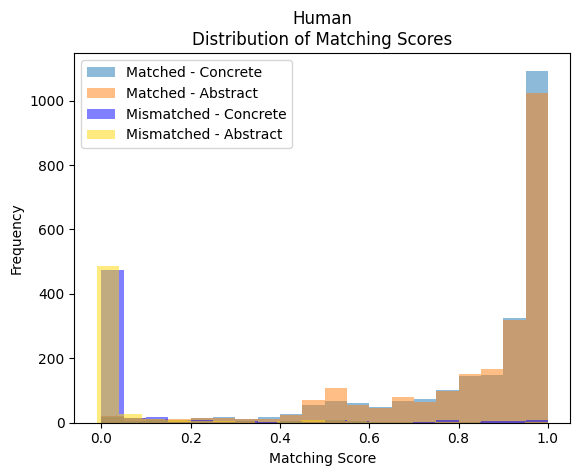

In [3]:
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'con')]['answer'], bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'abs')]['answer'], bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.hist(df_human[(df_human['match'] == 'mismatched') & (df_human['condition'] == 'con')]['answer'], bins=20, color='blue', alpha=0.5, label='Mismatched - Concrete')
plt.hist(df_human[(df_human['match'] == 'mismatched') & (df_human['condition'] == 'abs')]['answer'], bins=20, color='gold', alpha=0.5, label='Mismatched - Abstract')
plt.xlabel('Matching Score')
plt.ylabel('Frequency')
plt.title('Human\nDistribution of Matching Scores')
plt.legend()
plt.show()

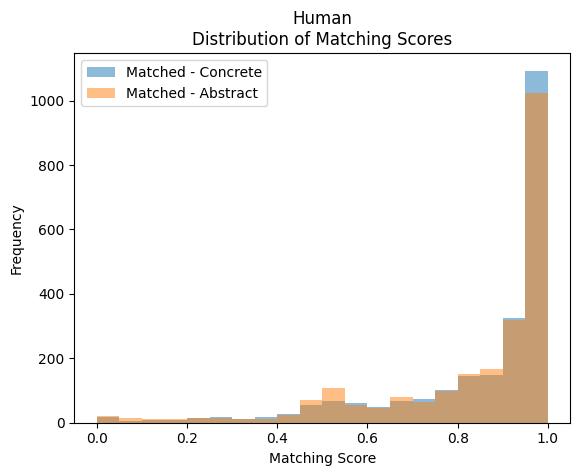

In [4]:
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'con')]['answer'], bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'abs')]['answer'], bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.xlabel('Matching Score')
plt.ylabel('Frequency')
plt.title('Human\nDistribution of Matching Scores')
plt.legend()
plt.show()

## Human Model Alignment

In [3]:
df_clip = pd.read_csv("/home/jinhanz/cs/concreteness/processing/stimuli_average/20250723_193742/captions_and_attributes.csv")
df_clip = df_clip.sort_values(by='image_id')

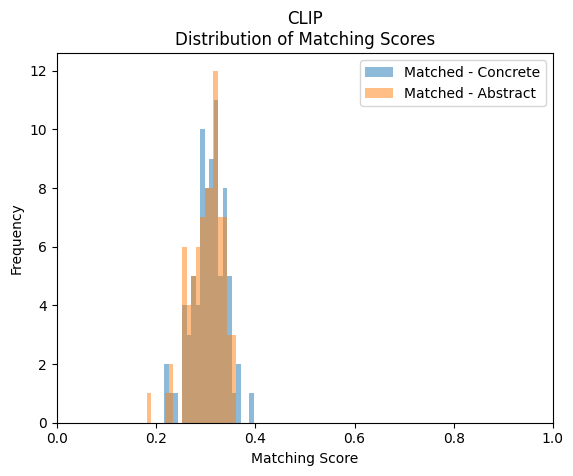

In [6]:
plt.hist(df_clip['con_matching_score'], bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(df_clip['abs_matching_score'], bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.xlabel('Matching Score')
plt.ylabel('Frequency')
plt.xlim(0, 1)
plt.title('CLIP\nDistribution of Matching Scores')
plt.legend()
plt.show()

### By-subject

In [9]:
subjs = df_human['subject_no'].unique()
subj_num = len(subjs)

alignment_con = np.zeros(subj_num)
alignment_abs = np.zeros(subj_num)

for s, subj in enumerate(subjs):
    df_subj = df_human[(df_human['match'] == 'matched') & (df_human['subject_no']==subj)]
    df_subj_con = df_subj[df_subj['condition'] == 'con'].sort_values(by='image_id')
    df_subj_abs = df_subj[df_subj['condition'] == 'abs'].sort_values(by='image_id')

    assert df_subj_con['image_id'].tolist() == df_clip['image_id'].tolist()
    assert df_subj_abs['image_id'].tolist() == df_clip['image_id'].tolist()

    alignment_con[s] = np.corrcoef(df_subj_con['answer'], df_clip["con_matching_score"])[0,1]
    alignment_abs[s] = np.corrcoef(df_subj_abs['answer'], df_clip["abs_matching_score"])[0,1]

KeyboardInterrupt: 

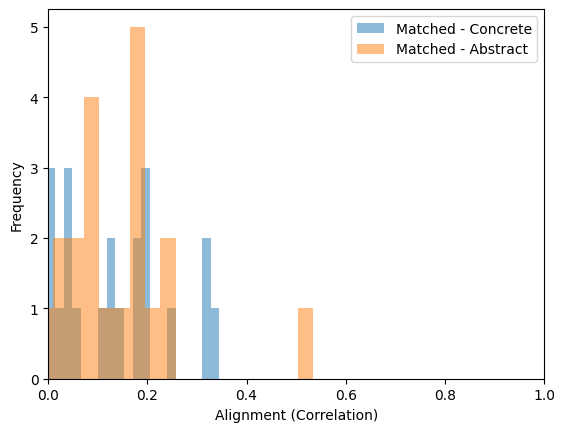

In [47]:
plt.hist(alignment_con, bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(alignment_abs, bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.xlabel('Alignment (Correlation)')
plt.ylabel('Frequency')
plt.xlim(0, 1)
# plt.title('CLIP\nDistribution of Matching Scores')
plt.legend()
plt.show()

In [32]:
t_stat, p_value = ttest_rel(alignment_con, alignment_abs)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 0.1459194106473123, P-value: 0.8854457077347055


#### By item

In [8]:
df_human = df_human[df_human['match'] == 'matched']
df_human['answer_normalized'] = df_human.groupby('subject_no')['answer'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
df_human

,subject_no,answer,practicestatus,Trial_Index_,imagename,block_name,image_id,match,condition,answer_normalized
0,24,0.95,experimental,1,matched_con_COCO_val2014_000000540159.jpg,1,val2014/COCO_val2014_000000540159.jpg,matched,con,0.946809
1,24,0.99,experimental,2,matched_con_COCO_val2014_000000220739.jpg,1,val2014/COCO_val2014_000000220739.jpg,matched,con,0.989362
3,24,0.42,experimental,4,matched_con_COCO_val2014_000000179273.jpg,1,val2014/COCO_val2014_000000179273.jpg,matched,con,0.382979
6,24,0.54,experimental,7,matched_con_COCO_val2014_000000204311.jpg,1,val2014/COCO_val2014_000000204311.jpg,matched,con,0.510638
7,24,0.51,experimental,8,matched_abs_COCO_val2014_000000391539.jpg,1,val2014/COCO_val2014_000000391539.jpg,matched,abs,0.478723
...,...,...,...,...,...,...,...,...,...,...
5794,29,1.0,experimental,45,matched_abs_COCO_val2014_000000001340.jpg,4,val2014/COCO_val2014_000000001340.jpg,matched,abs,1.0
5795,29,1.0,experimental,46,matched_con_COCO_val2014_000000326550.jpg,4,val2014/COCO_val2014_000000326550.jpg,matched,con,1.0
5796,29,1.0,experimental,47,matched_abs_COCO_val2014_000000057495.jpg,4,val2014/COCO_val2014_000000057495.jpg,matched,abs,1.0
5798,29,1.0,experimental,49,matched_abs_COCO_val2014_000000147030.jpg,4,val2014/COCO_val2014_000000147030.jpg,matched,abs,1.0


In [10]:
min_score = min(df_clip['abs_matching_score'].min(), df_clip['con_matching_score'].min())
max_score = max(df_clip['abs_matching_score'].max(), df_clip['con_matching_score'].max())

df_clip['abs_matching_score_normalized'] = (df_clip['abs_matching_score'] - min_score) / (max_score - min_score)
df_clip['con_matching_score_normalized'] = (df_clip['con_matching_score'] - min_score) / (max_score - min_score)
df_clip

,image_id,capion_concreteness_diff,abstract_caption,concrete_caption,abs_matching_score,con_matching_score,abs_word_importances,con_word_importances,abs_char_number,con_char_number,...,abs_word_frequency,con_word_frequency,abs_emap_var,con_emap_var,abs_abstract_score,con_abstract_score,abs_concrete_score,con_concrete_score,abs_matching_score_normalized,con_matching_score_normalized
33,val2014/COCO_val2014_000000001340.jpg,0.991667,This is a creative use of leaves and small ree...,A clear vase with flowers sitting a little table.,0.317871,0.278320,0.221973,0.341585,67,49,...,1.249456e+06,9.183610e+05,0.036804,0.035431,3.321667,4.313333,3.321667,4.313333,0.632976,0.450028
21,val2014/COCO_val2014_000000003310.jpg,1.124857,The woman is enjoying her very large hot dog.,A person holding a napkin and eating a hotdog.,0.316895,0.339844,0.172899,0.252421,45,46,...,2.718475e+06,4.649556e+05,0.013634,0.014984,3.377143,4.502000,3.377143,4.502000,0.628458,0.734613
24,val2014/COCO_val2014_000000016546.jpg,1.111429,Two skiers are passing each other on the slope,Two people are walking with ski poles in the s...,0.273193,0.317383,0.137469,0.303992,46,50,...,1.040301e+07,2.043196e+07,0.014854,0.017670,3.235714,4.347143,3.235714,4.347143,0.426313,0.630717
76,val2014/COCO_val2014_000000017921.jpg,0.621429,An elegant style bed with white drapes hung fr...,A bed covered in white linen in a bedroom with...,0.339844,0.309814,0.403809,0.414431,57,57,...,7.954753e+05,1.811790e+07,0.029449,0.019104,3.658571,4.280000,3.658571,4.280000,0.734613,0.595709
4,val2014/COCO_val2014_000000020459.jpg,1.314286,Two men playing competitive frisbee against ea...,Two people wearing jerseys are playing with a ...,0.325439,0.294434,0.347054,0.245508,55,54,...,4.036676e+06,3.818531e+06,0.013390,0.016220,3.055714,4.370000,3.055714,4.370000,0.667984,0.524562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,val2014/COCO_val2014_000000561681.jpg,1.100667,A plate that has different type of foods on it.,"A plate topped with rice, meat and vegetables.",0.276123,0.299561,0.196523,0.485550,47,46,...,1.713092e+07,1.483576e+05,0.037415,0.034271,3.483333,4.584000,3.483333,4.584000,0.439864,0.548278
74,val2014/COCO_val2014_000000565485.jpg,0.653333,An empty train station with people waiting aro...,A red bench and a person in a train station.,0.301270,0.274658,0.368553,0.278021,50,44,...,2.739965e+06,2.129474e+07,0.019257,0.012093,3.670000,4.323333,3.670000,4.323333,0.556183,0.433089
69,val2014/COCO_val2014_000000568505.jpg,0.670000,A bed with a pillow at the tip is neatly made.,A canopy bed in a white and brown room,0.271484,0.313965,0.239418,0.197791,47,39,...,5.967041e+06,2.134648e+07,0.029892,0.039490,3.610000,4.280000,3.610000,4.280000,0.418408,0.614907
70,val2014/COCO_val2014_000000570394.jpg,0.669714,Looking down at cookies baking in a home oven,An oven with cakes inside in a kitchen,0.307861,0.300293,0.356177,0.317404,45,38,...,2.331844e+07,2.505970e+07,0.015320,0.024292,3.614286,4.284000,3.614286,4.284000,0.586674,0.551666


In [11]:
imgs = df_clip['image_id'].unique()
img_num = len(imgs)

score_mean_con = np.zeros(img_num)
score_mean_abs = np.zeros(img_num)
score_clip_con = np.zeros(img_num)
score_clip_abs = np.zeros(img_num)

for i, img in enumerate(imgs):
    df_img = df_human[(df_human['match'] == 'matched') & (df_human['image_id']==img)]
    score_mean_con[i] = df_img[df_img['condition'] == 'con']['answer_normalized'].mean()
    score_mean_abs[i] = df_img[df_img['condition'] == 'abs']['answer_normalized'].mean()

    score_clip_con[i] = df_clip[df_clip['image_id'] == img]['con_matching_score_normalized'].values[0]
    score_clip_abs[i] = df_clip[df_clip['image_id'] == img]['abs_matching_score_normalized'].values[0]

In [12]:
from scipy.stats import pearsonr
from statsmodels.stats.anova import AnovaRM
import pandas as pd

# Prepare the data for ANOVA
# 'Condition' (Concrete vs Abstract) is a within-subject factor, not a between-subject factor.
data = pd.DataFrame({
    'Image': list(range(1, img_num + 1)) * 2,
    'Condition': ['Concrete'] * img_num + ['Abstract'] * img_num,
    'Human': np.concatenate([score_mean_con, score_mean_abs]),
    'CLIP': np.concatenate([score_clip_con, score_clip_abs])
})

# Melt the data for repeated measures ANOVA
data_melted = pd.melt(data, id_vars=['Image', 'Condition'], value_vars=['Human', 'CLIP'], 
                      var_name='Model', value_name='Score')

# anova_results_rm = AnovaRM(data_melted, 'Score', 'Image', 
#                            within=['Model'], 
#                            between=['Condition']).fit()

# print(anova_results_rm)

In [13]:
data.to_csv("anova_normalized.csv")

maybe also test human accuracy on matched vs mismatched?